In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Setup


In [ ]:
# %cd /content/drive/MyDrive
# !git clone https://github.com/jadelaossa/automatic-receipts-recognition.git

/content/drive/MyDrive
Cloning into 'automatic-receipts-recognition'...
remote: Enumerating objects: 258, done.
remote: Counting objects: 100% (258/258), done.
remote: Compressing objects: 100% (247/247), done.
remote: Total 258 (delta 9), reused 257 (delta 8), pack-reused 0
Receiving objects: 100% (258/258), 5.99 MiB | 10.62 MiB/s, done.
Resolving deltas: 100% (9/9), done.
Updating files: 100% (232/232), done.


In [ ]:
%cd /content/drive/MyDrive

/content/drive/MyDrive


In [ ]:
%cd automatic-receipts-recognition
!pip install ultralytics

/content/drive/MyDrive/automatic-receipts-recognition
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached 

# 1. Entrenamiento

In [ ]:
# !python train.py

In [ ]:
from ultralytics import YOLO

# load pre-trained model
model = YOLO("yolov8n.pt")

# train the model
results = model.train(
    data="config.yaml",
    epochs=300,
    imgsz=640
)

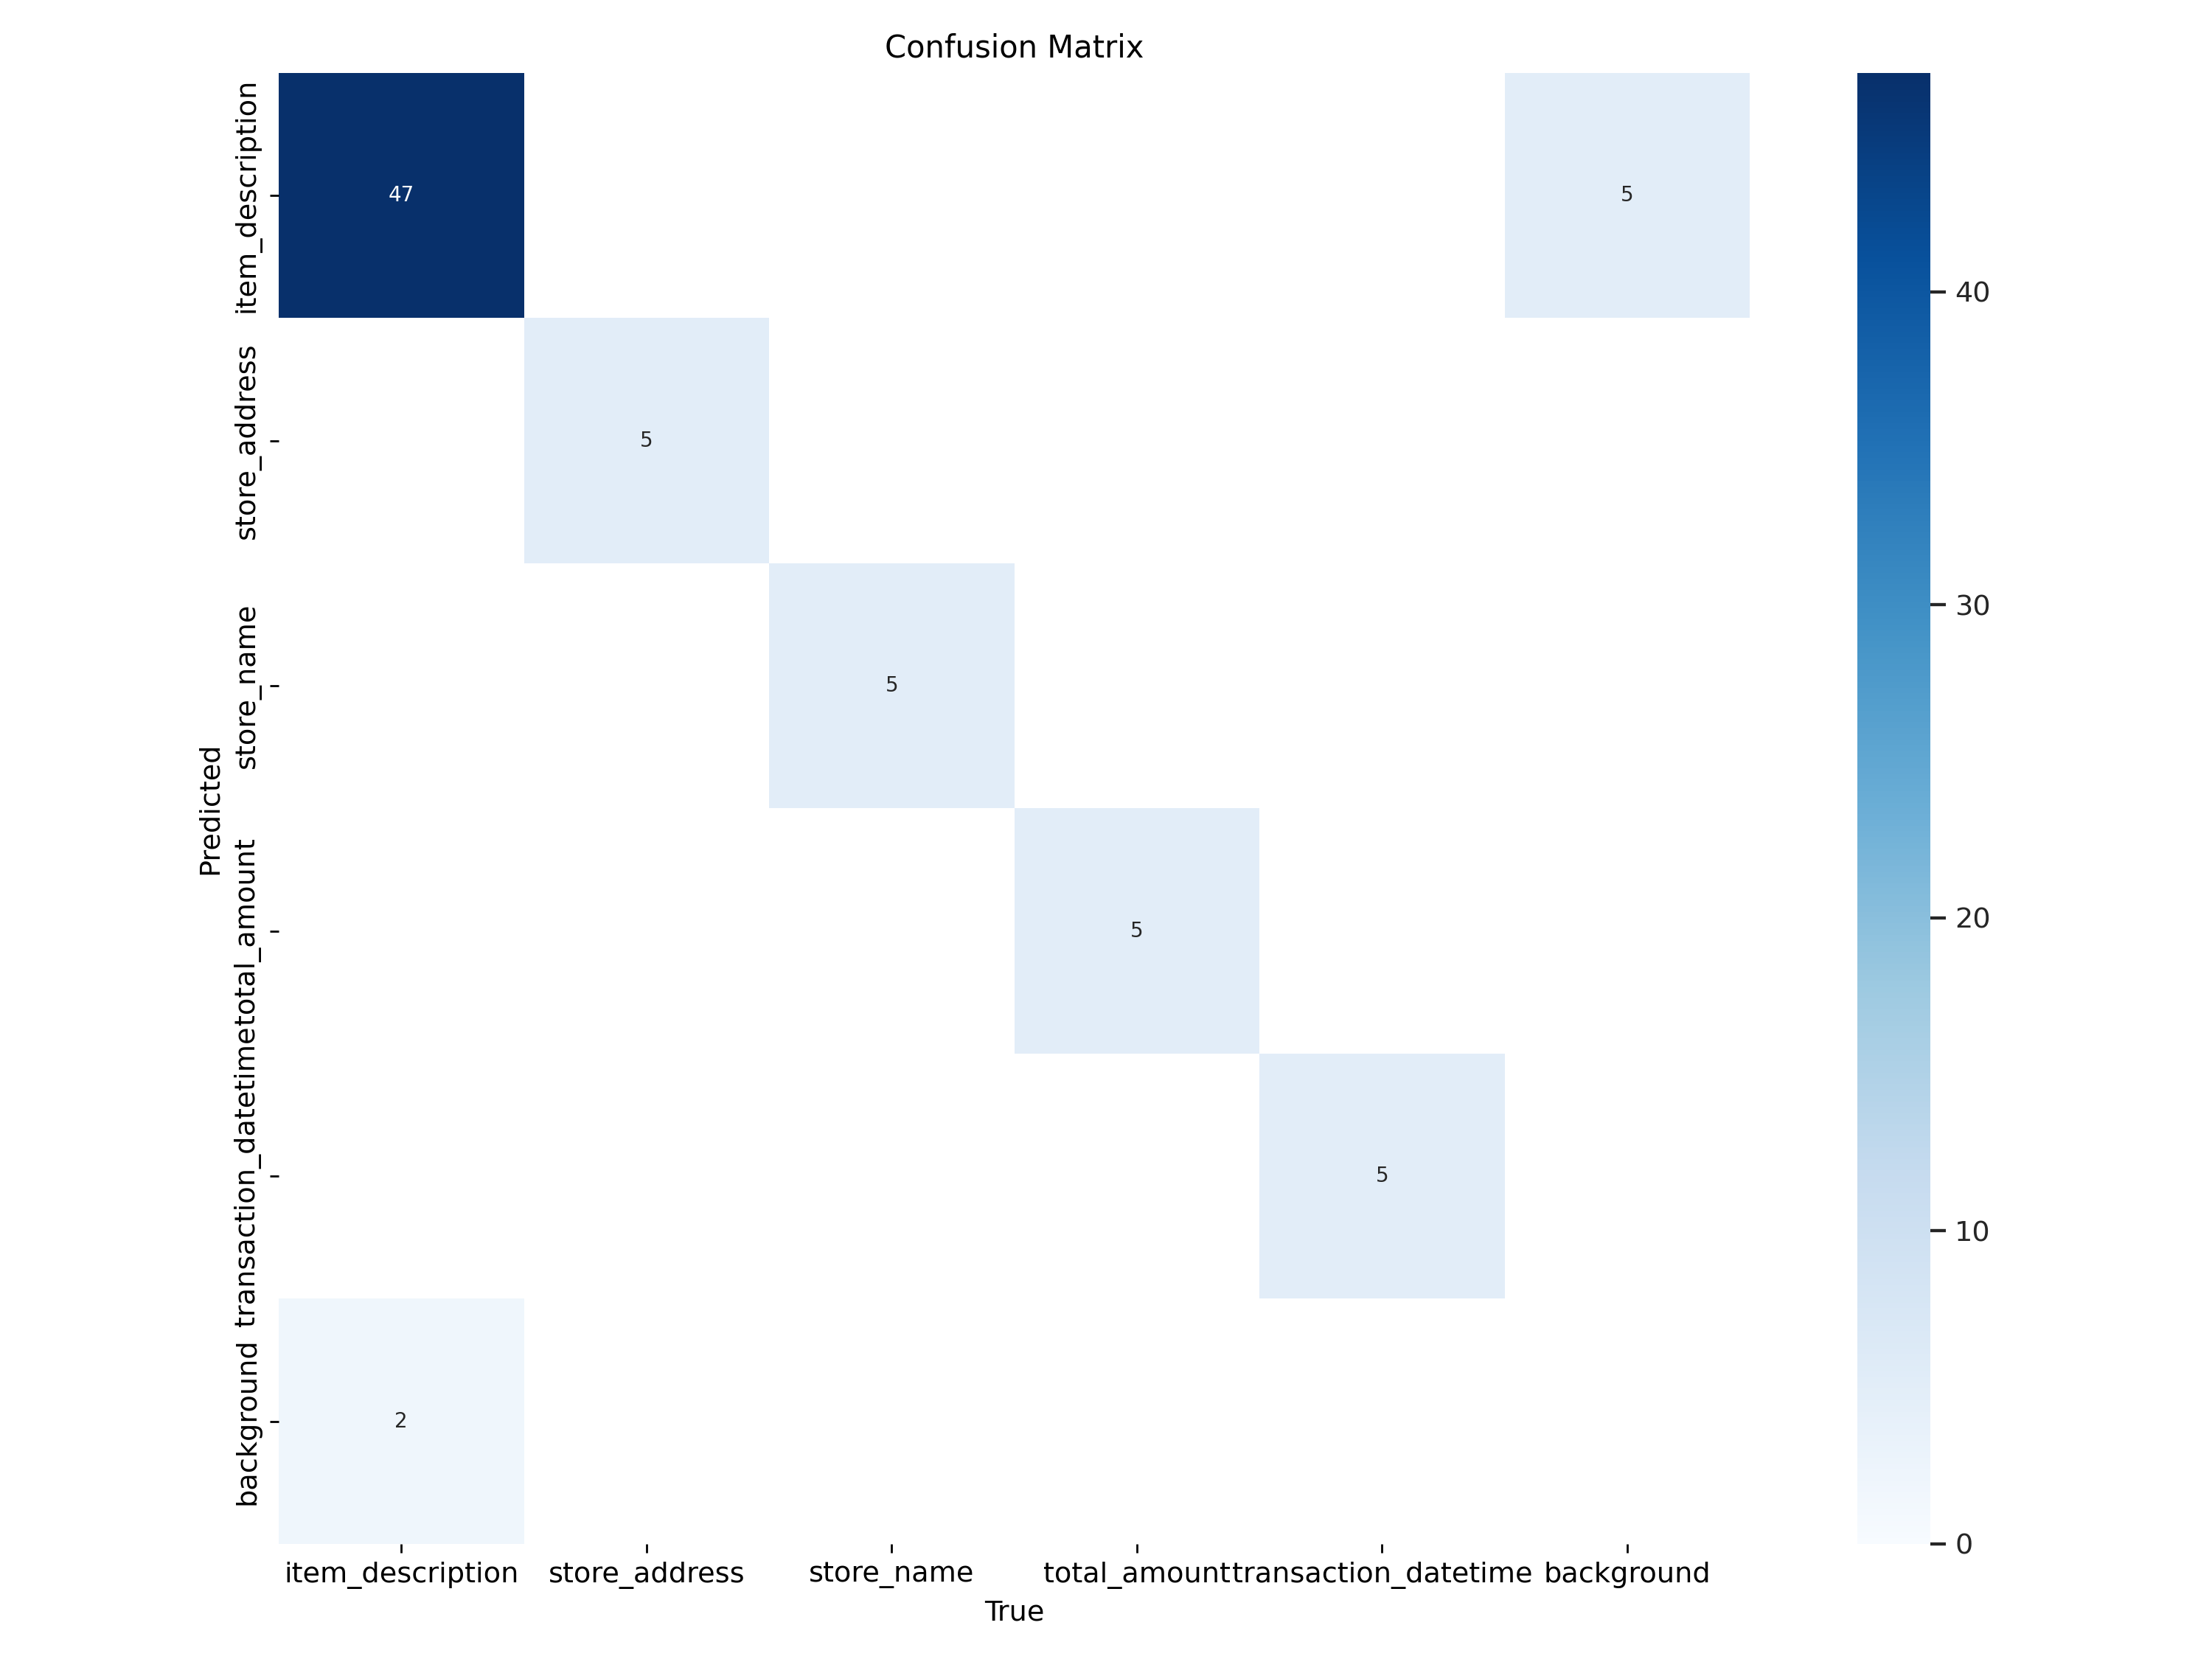

In [ ]:
from IPython.display import display, Image

Image("./runs/detect/train7/confusion_matrix.png", width=800)

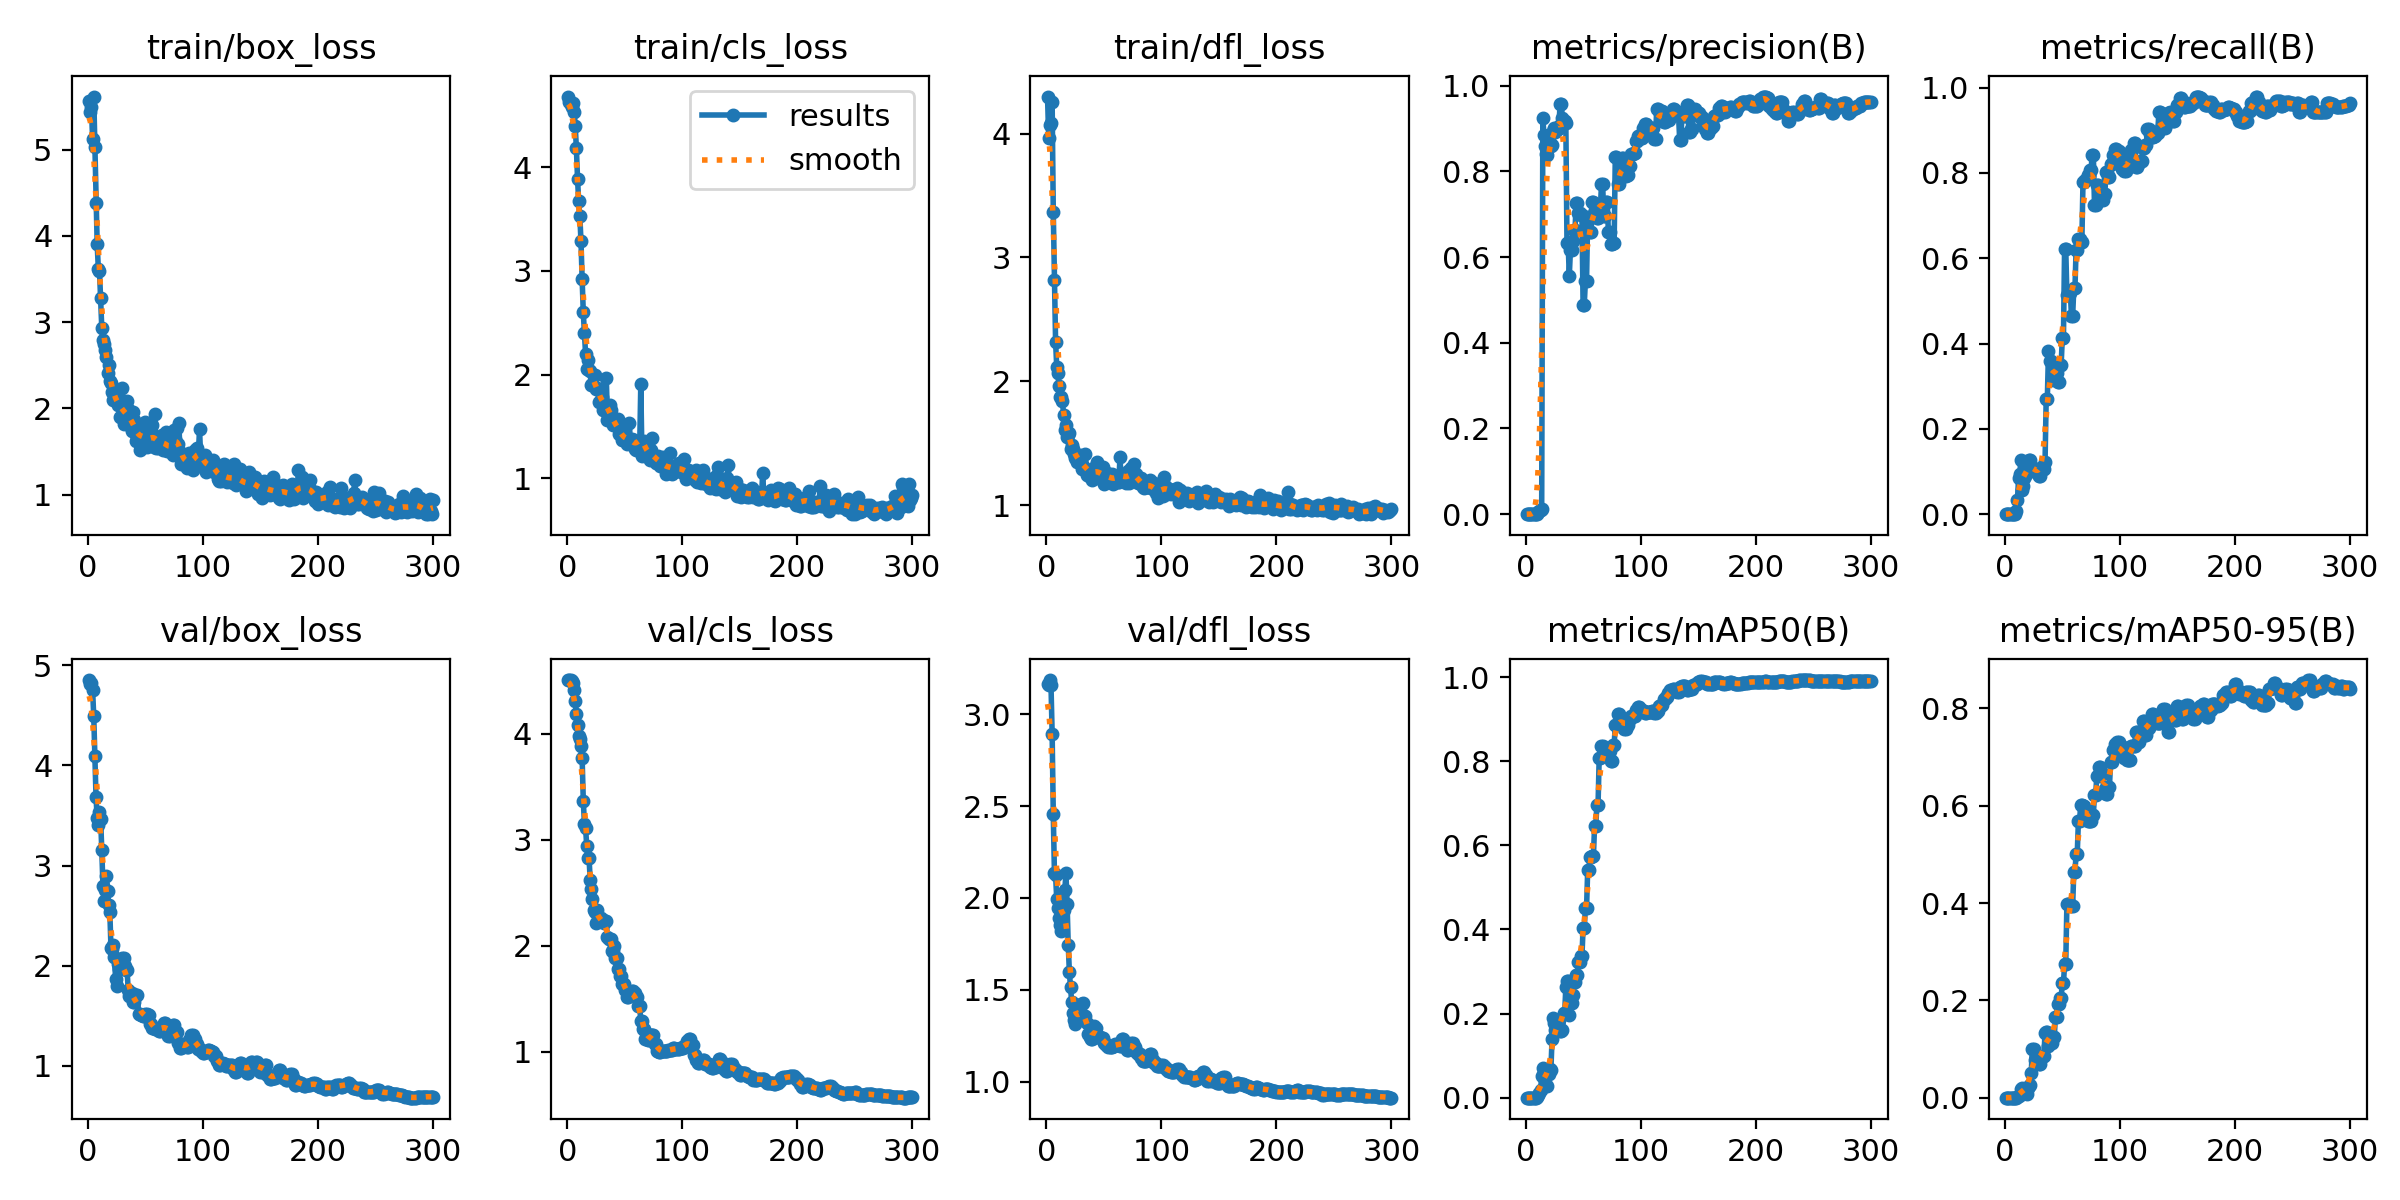

In [ ]:
Image("./runs/detect/train7/results.png", width=800)

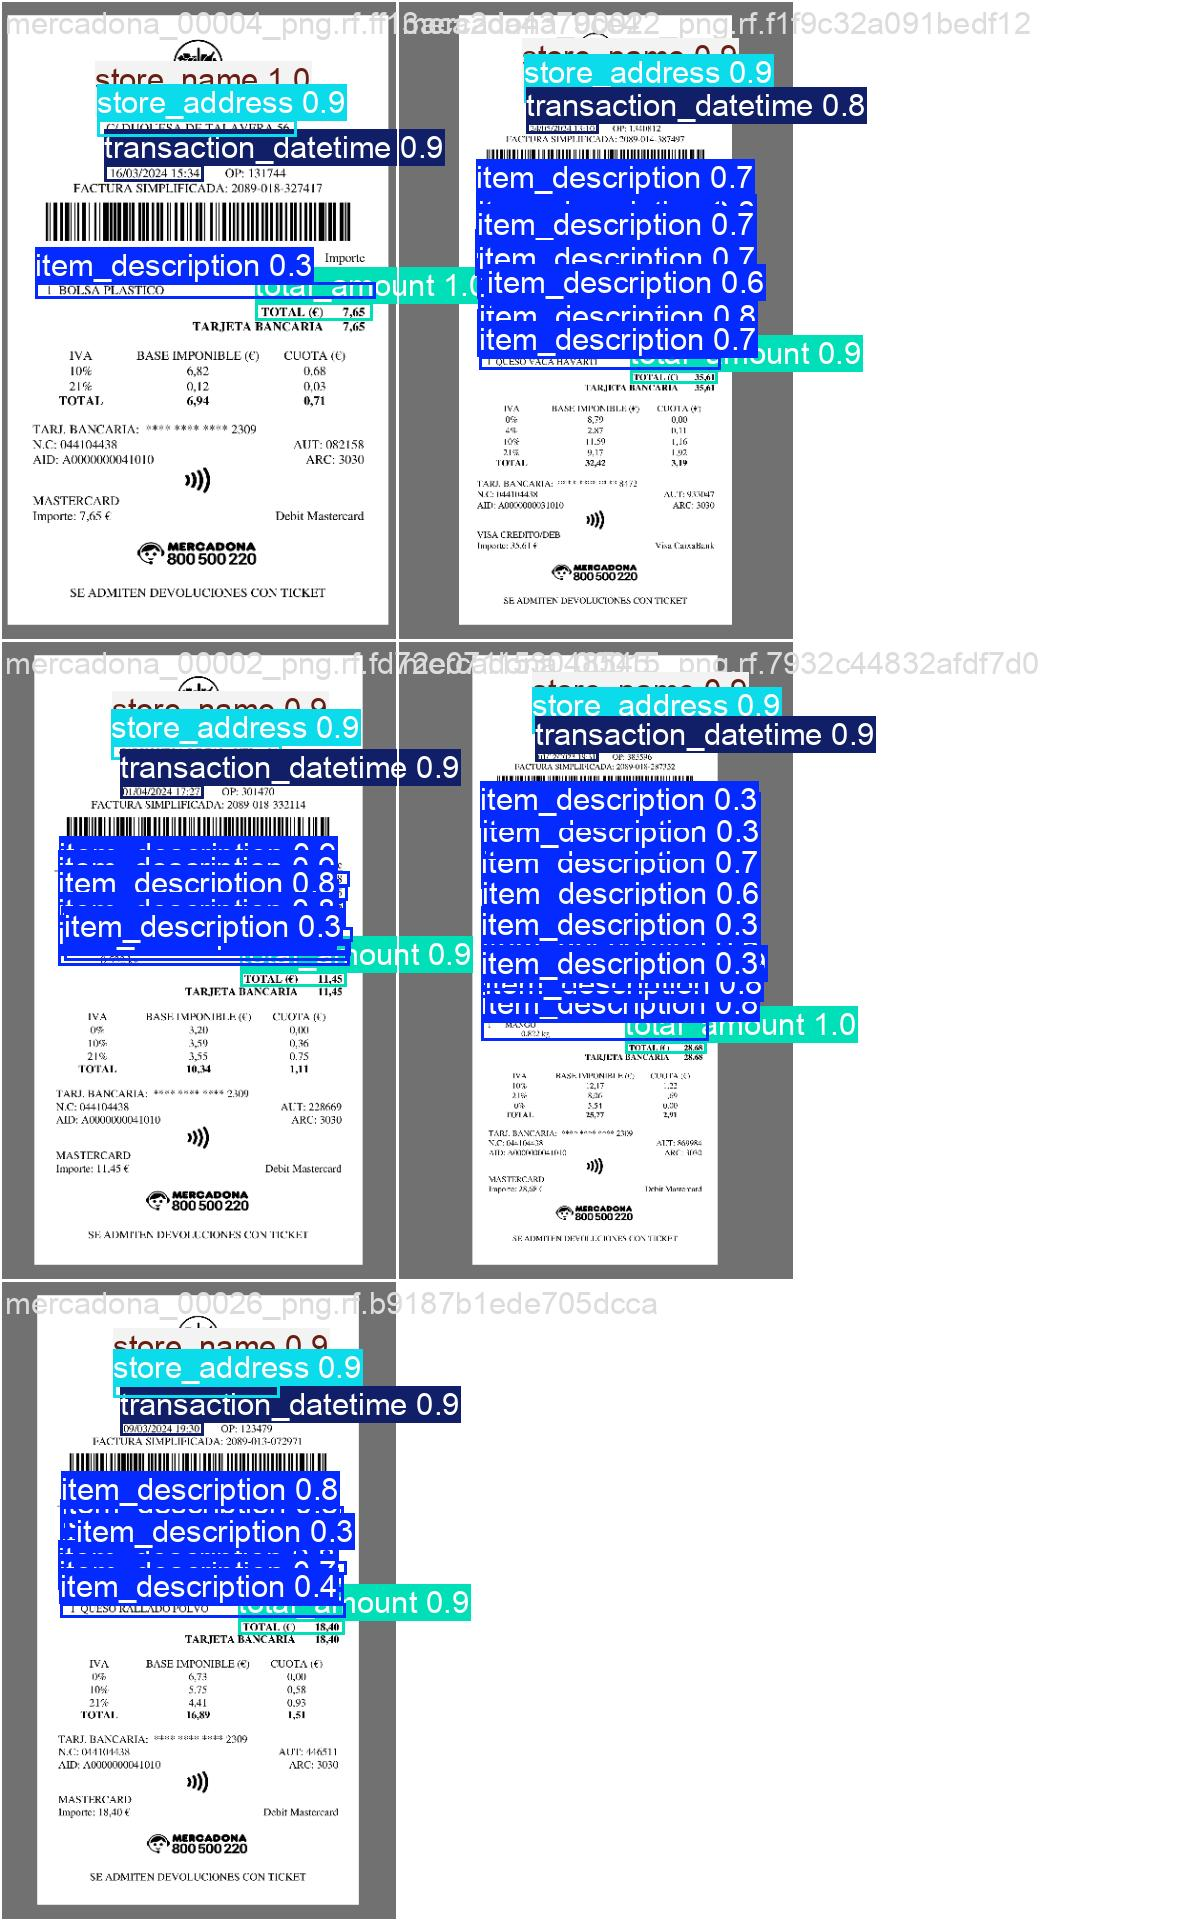

In [ ]:
Image("./runs/detect/train7/val_batch0_pred.jpg", width=800)

# 2. Predicción

In [ ]:
# !python predict.py

In [ ]:
from ultralytics import YOLO

# load the model
model = YOLO("runs/detect/train7/weights/best.pt")

In [ ]:
# run batched inference on a list of images
results = model([
    "data/digital/mercadona/test/images/mercadona_00005_png.rf.48f6aadd10ac7b48836d3f9f1ee466f0.jpg",
    "data/digital/mercadona/test/images/mercadona_00009_png.rf.016153500a13c8cf8e1ff13c64097c14.jpg",
    "data/digital/mercadona/test/images/mercadona_00024_png.rf.9ae1f4e674336aae3a7aac9f177218a8.jpg"
])


0: 640x640 29 item_descriptions, 1 store_address, 1 store_name, 1 total_amount, 2 transaction_datetimes, 41.3ms
1: 640x640 14 item_descriptions, 1 store_address, 1 store_name, 1 total_amount, 1 transaction_datetime, 41.3ms
2: 640x640 1 item_description, 1 store_address, 1 store_name, 1 total_amount, 1 transaction_datetime, 41.3ms
Speed: 10.1ms preprocess, 41.3ms inference, 266.4ms postprocess per image at shape (1, 3, 640, 640)


# 3. Almacenamiento de los *crops* de las clases predecidas

In [ ]:
for idx, result in enumerate(results):
  result_path = result.path.split("/")[-1]
  result.save_crop(save_dir=f"./crops/{result_path}", file_name=f"detection")

# 4. Conversión de imagen a texto (OCR)

## 4.1. Setup Pytesseract

In [ ]:
!sudo apt-get update
!sudo apt-get install -y tesseract-ocr
!pip install pytesseract

import pytesseract

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Ign:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy Release
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading pac

## 4.2. Setup EasyOCR

In [ ]:
!pip install easyocr

import easyocr
reader = easyocr.Reader(["es", "en"])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.3/908.3 kB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.3/281.3 kB 26.9 MB/s eta 0:00:00


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

TOTAL_AMOUNT:


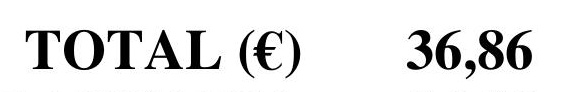

Pytesseract prediction: TOTAL (€) 36,86

EasyOCR prediction: TOTAL (€) 36,86

STORE_NAME:


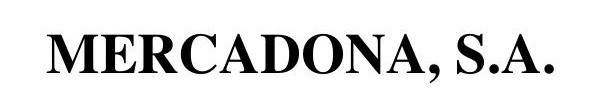

Pytesseract prediction: MERCADONA, S.A.

EasyOCR prediction: MERCADONA, S.A

TRANSACTION_DATETIME:


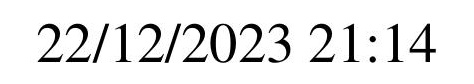

Pytesseract prediction: 22/12/2023 21:14

EasyOCR prediction: 22/12/2023 21.14

STORE_ADDRESS:


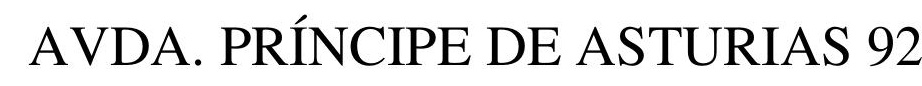

Pytesseract prediction: AVDA. PRINCIPE DE ASTURIAS 92

EasyOCR prediction: AVDA. PRINCIPE DE ASTURIAS 92



In [ ]:
import os
import glob
from PIL import Image

CROPS_DIR = "./crops/"

last_receipt_folder = glob.glob(f"{CROPS_DIR}*")[-2]
classes_folders = glob.glob(f"{last_receipt_folder}/*")

for class_folder in classes_folders:
  class_label = class_folder.split("/")[-1]

  if class_label != "item_description":
    print(f"{class_label.upper()}:")
    crops_list = glob.glob(f"{class_folder}/*")

    for crop_path in crops_list:
      img = Image.open(crop_path)
      display(img)

      # Pytesseract
      text = pytesseract.image_to_string(crop_path, lang="eng+spa")
      print(f"Pytesseract prediction: {text}")

      # EasyOCR
      result = reader.readtext(crop_path, detail=0)
      print(f"EasyOCR prediction: {' '.join(result)}")

    print()

In [ ]:
receipt_data = {}

for class_folder in classes_folders:
  class_label = class_folder.split("/")[-1]

  if class_label != "item_description":
    crops_list = glob.glob(f"{class_folder}/*")
    crop_path = crops_list[0] # Si hubiera más de uno, me quedo con el primero. Por ahora...
    text = pytesseract.image_to_string(crop_path, lang="eng+spa")
    receipt_data[class_label] = text

print(receipt_data)

{'total_amount': 'TOTAL (€) 36,86\n\x0c', 'store_name': 'MERCADONA, S.A.\n\x0c', 'transaction_datetime': '22/12/2023 21:14\n\x0c', 'store_address': 'AVDA. PRINCIPE DE ASTURIAS 92\n\x0c'}


In [ ]:
import re

items = []

for class_folder in classes_folders:
  class_label = class_folder.split("/")[-1]

  if class_label == "item_description":
    crops_list = glob.glob(f"{class_folder}/*")

    for crop_path in crops_list:
      # Pytesseract
      text = pytesseract.image_to_string(crop_path, lang="eng+spa")
      cleaned_text = re.sub(r"[\x0c\n]", "", text)
      print(f"Pytesseract prediction: {cleaned_text}")

      # EasyOCR
      results = reader.readtext(crop_path, detail=0)
      print(f"EasyOCR prediction: {' '.join(results)}")

      print("======================================================")
      print()

Pytesseract prediction: 1 SALVAUNAS DELICADO 0,75
EasyOCR prediction: 1 SALVAUÑAS DELICADO 0,75

Pytesseract prediction: 1 VARITAS DIF JASMINE 2,15
EasyOCR prediction: 1 VARITAS DIF JASMINE 2,15

Pytesseract prediction: 1PIZZA JAMON M.FINA2,90
EasyOCR prediction: 1 PIZZA JAMON MFINA 2,50

Pytesseract prediction: 1 LECHE ENTERA P6 5,46
EasyOCR prediction: LECHE ENTERA P6 5,46

Pytesseract prediction: 1 CREMA CATALANA 2,40
EasyOCR prediction: 1 CREMA CATALANA 2,40

Pytesseract prediction: 1 NATILLAS VAINILLA 1,05
EasyOCR prediction: NATILLAS VAINILLA 1,05

Pytesseract prediction: 1 ZUMO NARANJA C/PULPA 1,75
EasyOCR prediction: 1 ZUMO NARANJA C/PULPA 1,75

Pytesseract prediction: 1PIZZA 4 QUESOS M.FIN2,90
EasyOCR prediction: 1 PIZZA 4 QUESOS MFIN 2,50

Pytesseract prediction: 1 Q RALLADO FUNDIR 2,05
EasyOCR prediction: 1 0 RALLADO FUNDIR 2,05

Pytesseract prediction: 1 OREGANO 0,95
EasyOCR prediction: 1 ORÉGANO 0,95

Pytesseract prediction: 1 ALMENDRA RELLENA 2,65
EasyOCR prediction: 1 AL

In [ ]:
import re

items = []

# pattern = r"^(?:(\d+)\s*)?([A-Za-z\s.,/-ÁÉÍÓÚÑáéíóúñ]+?)\s*(\d+[.,]?\d*)$"
pattern = r"^(\d*)\s*([A-Za-z\s.,/-ÁÉÍÓÚÑáéíóúñ]+?)(\d+[.,]?\d*)$"

for class_folder in classes_folders:
  class_label = class_folder.split("/")[-1]

  if class_label == "item_description":
    crops_list = glob.glob(f"{class_folder}/*")

    for crop_path in crops_list:
      # Pytesseract
      text = pytesseract.image_to_string(crop_path, lang="eng+spa")
      pytesseract_text = re.sub(r"[\x0c\n]", "", text)

      match = re.match(pattern, pytesseract_text)

      if match:
        quantity = match.group(1) if match.group(1) else "N/A" # quantity is optional
        description = match.group(2).strip()  # strip any leading/trailing whitespace
        price = match.group(3) if match.group(3) else "N/A" # price is optional
      else:
        continue

      print(f"Detected text: {pytesseract_text}")
      # print("Pytesseract detection:")
      print(f"- Quantity: {quantity}")
      print(f"- Description: {description}")
      print(f"- Price: {price}")

      item_dict = {
          "quantity": quantity,
          "description": description,
          "price": price
      }

      items.append(item_dict)

      print("------------------------------------------------------")

      # EasyOCR
      results = reader.readtext(crop_path, detail=0)
      easyocr_text = " ".join(results)

      match = re.match(pattern, easyocr_text)
      print(f"Regular expression match result (EasyOCR): {match}")
      print(f"EasyOCR prediction: {easyocr_text}")

      print("======================================================")
print()

Detected text: 1 SALVAUNAS DELICADO 0,75
- Quantity: 1
- Description: SALVAUNAS DELICADO
- Price: 0,75
------------------------------------------------------
Regular expression match result (EasyOCR): <re.Match object; span=(0, 25), match='1 SALVAUÑAS DELICADO 0,75'>
EasyOCR prediction: 1 SALVAUÑAS DELICADO 0,75
Detected text: 1 VARITAS DIF JASMINE 2,15
- Quantity: 1
- Description: VARITAS DIF JASMINE
- Price: 2,15
------------------------------------------------------
Regular expression match result (EasyOCR): <re.Match object; span=(0, 26), match='1 VARITAS DIF JASMINE 2,15'>
EasyOCR prediction: 1 VARITAS DIF JASMINE 2,15
Detected text: 1PIZZA JAMON M.FINA2,90
- Quantity: 1
- Description: PIZZA JAMON M.FINA
- Price: 2,90
------------------------------------------------------
Regular expression match result (EasyOCR): <re.Match object; span=(0, 24), match='1 PIZZA JAMON MFINA 2,50'>
EasyOCR prediction: 1 PIZZA JAMON MFINA 2,50
Detected text: 1 LECHE ENTERA P6 5,46
- Quantity: 1
- Desc

In [ ]:
import pytesseract

def pytesseract_text_extraction(image_path: str, lang: str = "eng+spa") -> str:
    """
    Extracts text from an image using pytesseract and cleans it by removing unwanted characters.

    :param image_path (str): Path to the image file.
    :param lang (str): Language(s) to be used by pytesseract for OCR. Default is "eng+spa".
    :return cleaned_text (str): The extracted and cleaned text.
    """
    # Perform OCR to extract text
    text = pytesseract.image_to_string(image_path, lang=lang)

    # Clean the text by removing unwanted characters
    cleaned_text = re.sub(r"[\x0c\n]", "", text)

    return cleaned_text

In [ ]:
import json
import re

receipt_data = {}

total_amount_pattern = r"(\d+[.,]?\d+)"
items_pattern = r"^(\d*)\s*([A-Za-z\s.,/-ÁÉÍÓÚÑáéíóúñ]+?)(\d+[.,]?\d*)$"

for class_folder in classes_folders:
  class_label = class_folder.split("/")[-1]
  crops_list = glob.glob(f"{class_folder}/*")

  if class_label != "item_description":
    crop_path = crops_list[0] # If there is more than one, takes just the first one

    # text = pytesseract.image_to_string(crop_path, lang="eng+spa")
    # cleaned_text = re.sub(r"[\x0c\n]", "", text)
    cleaned_text = pytesseract_text_extraction(crop_path)

    if class_label == "total_amount":
      match = re.search(total_amount_pattern, cleaned_text)
      if match:
        cleaned_text = float(match.group(1).replace(",", "."))

    receipt_data[class_label] = cleaned_text

  else:
    items = []

    for crop_path in crops_list:
      # text = pytesseract.image_to_string(crop_path, lang="eng+spa")
      # cleaned_text = re.sub(r"[\x0c\n]", "", text)
      cleaned_text = pytesseract_text_extraction(crop_path)

      match = re.match(items_pattern, cleaned_text)

      if match:
        quantity = int(match.group(1)) if match.group(1) else 1 # quantity is optional. Criteria is 1 in case no match
        description = match.group(2).strip()  # strip any leading/trailing whitespace
        price = float(match.group(3).replace(",", ".")) if match.group(3) else None # price is optional
      else:
        continue

      item_dict = {
          "quantity": quantity,
          "description": description,
          "price_eur": price
      }

      items.append(item_dict)

    receipt_data["items"] = items

print(json.dumps(receipt_data, indent=4))

{
    "total_amount": 36.86,
    "store_name": "MERCADONA, S.A.",
    "transaction_datetime": "22/12/2023 21:14",
    "items": [
        {
            "quantity": 1,
            "description": "SALVAUNAS DELICADO",
            "price_eur": 0.75
        },
        {
            "quantity": 1,
            "description": "VARITAS DIF JASMINE",
            "price_eur": 2.15
        },
        {
            "quantity": 1,
            "description": "PIZZA JAMON M.FINA",
            "price_eur": 2.9
        },
        {
            "quantity": 1,
            "description": "LECHE ENTERA P6",
            "price_eur": 5.46
        },
        {
            "quantity": 1,
            "description": "CREMA CATALANA",
            "price_eur": 2.4
        },
        {
            "quantity": 1,
            "description": "NATILLAS VAINILLA",
            "price_eur": 1.05
        },
        {
            "quantity": 1,
            "description": "ZUMO NARANJA C/PULPA",
            "price_eur": 1.75


In [ ]:
import pandas as pd

receipt_details = {key: value for key, value in receipt_data.items() if key != "items"}

df_receipt_details = pd.DataFrame([receipt_details])
df_receipt_items = pd.DataFrame(receipt_data["items"])

pd.concat([df_receipt_details, df_receipt_items], axis=1).ffill()

,total_amount,store_name,transaction_datetime,store_address,quantity,description,price_eur
0,36.86,"MERCADONA, S.A.",22/12/2023 21:14,AVDA. PRINCIPE DE ASTURIAS 92,1,SALVAUNAS DELICADO,0.75
1,36.86,"MERCADONA, S.A.",22/12/2023 21:14,AVDA. PRINCIPE DE ASTURIAS 92,1,VARITAS DIF JASMINE,2.15
2,36.86,"MERCADONA, S.A.",22/12/2023 21:14,AVDA. PRINCIPE DE ASTURIAS 92,1,PIZZA JAMON M.FINA,2.90
3,36.86,"MERCADONA, S.A.",22/12/2023 21:14,AVDA. PRINCIPE DE ASTURIAS 92,1,LECHE ENTERA P6,5.46
4,36.86,"MERCADONA, S.A.",22/12/2023 21:14,AVDA. PRINCIPE DE ASTURIAS 92,1,CREMA CATALANA,2.40
5,36.86,"MERCADONA, S.A.",22/12/2023 21:14,AVDA. PRINCIPE DE ASTURIAS 92,1,NATILLAS VAINILLA,1.05
6,36.86,"MERCADONA, S.A.",22/12/2023 21:14,AVDA. PRINCIPE DE ASTURIAS 92,1,ZUMO NARANJA C/PULPA,1.75
7,36.86,"MERCADONA, S.A.",22/12/2023 21:14,AVDA. PRINCIPE DE ASTURIAS 92,1,PIZZA 4 QUESOS M.FIN,2.90
8,36.86,"MERCADONA, S.A.",22/12/2023 21:14,AVDA. PRINCIPE DE ASTURIAS 92,1,Q RALLADO FUNDIR,2.05
9,36.86,"MERCADONA, S.A.",22/12/2023 21:14,AVDA. PRINCIPE DE ASTURIAS 92,1,OREGANO,0.95


In [ ]:
import easyocr

def easyocr_text_extraction(reader: easyocr.easyocr.Reader, image_path: str) -> str:
    """
    Extracts text from an image using EasyOCR and return a string will all the extractions
    separated by a space.

    :param reader (easyocr.easyocr.Reader): EasyOCR model.
    :param image_path (str): Language(s) to be used by pytesseract for OCR. Default is "eng+spa".
    :return cleaned_text (str): The extracted and cleaned text.
    """

    # Perform OCR to extract text
    results = reader.readtext(image_path, detail=0)

    # Join all the text bits together
    cleaned_text = " ".join(results)

    return cleaned_text

In [ ]:
import json
import re

receipt_data = {}

total_amount_pattern = r"(\d+[.,]?\d+)"
items_pattern = r"^(\d*)\s*([A-Za-z\s.,/-ÁÉÍÓÚÑáéíóúñ]+?)(\d+[.,]?\d*)$"

for class_folder in classes_folders:
  class_label = class_folder.split("/")[-1]
  crops_list = glob.glob(f"{class_folder}/*")

  if class_label != "item_description":
    crop_path = crops_list[0] # If there is more than one, takes just the first one

    cleaned_text = easyocr_text_extraction(reader, crop_path)

    if class_label == "total_amount":
      match = re.search(total_amount_pattern, cleaned_text)
      if match:
        cleaned_text = float(match.group(1).replace(",", "."))

    receipt_data[class_label] = cleaned_text

  else:
    items = []

    for crop_path in crops_list:
      cleaned_text = easyocr_text_extraction(reader, crop_path)

      match = re.match(items_pattern, cleaned_text)

      if match:
        quantity = int(match.group(1)) if match.group(1) else 1 # quantity is optional. Criteria is 1 in case no match
        description = match.group(2).strip()  # strip any leading/trailing whitespace
        price = float(match.group(3).replace(",", ".")) if match.group(3) else None # price is optional
      else:
        continue

      item_dict = {
          "quantity": quantity,
          "description": description,
          "price_eur": price
      }

      items.append(item_dict)

    receipt_data["items"] = items

print(json.dumps(receipt_data, indent=4))

{
    "total_amount": 36.86,
    "store_name": "MERCADONA, S.A",
    "transaction_datetime": "22/12/2023 21.14",
    "items": [
        {
            "quantity": 1,
            "description": "SALVAU\u00d1AS DELICADO",
            "price_eur": 0.75
        },
        {
            "quantity": 1,
            "description": "VARITAS DIF JASMINE",
            "price_eur": 2.15
        },
        {
            "quantity": 1,
            "description": "PIZZA JAMON MFINA",
            "price_eur": 2.5
        },
        {
            "quantity": 1,
            "description": "LECHE ENTERA P6",
            "price_eur": 5.46
        },
        {
            "quantity": 1,
            "description": "CREMA CATALANA",
            "price_eur": 2.4
        },
        {
            "quantity": 1,
            "description": "NATILLAS VAINILLA",
            "price_eur": 1.05
        },
        {
            "quantity": 1,
            "description": "ZUMO NARANJA C/PULPA",
            "price_eur": 1.

In [ ]:
import json
import os

def save_receipt_data(data: dict, file_name: str) -> None:
    """
    Saves a dictionary to a JSON file.

    :param data (dict): The dictionary to save.
    :param file_name (str): The name of the file to save the JSON to.
    """
    # Ensure the directory exists
    os.makedirs("./data/results/", exist_ok=True)

    with open(f"./data/results/{file_name}.json", "w") as f:
      json.dump(data, f, indent=4)

In [ ]:
save_receipt_data(receipt_data, last_receipt_folder.split("/")[-1])

In [ ]:
'''
# Estructura tipo de datos

data = {
  "store_name": store_name,
  "store_address": store_address,
  "total_amount": total_amount,
  "transaction_datetime": transaction_datetime,
  "items": [
    {"quantity": item_quantity, "description": item_desc, "price": price},
    {"quantity": item_quantity, "description": item_desc, "price": price},
    {"quantity": item_quantity, "description": item_desc, "price": price},
    ...
  ]
}
'''

'\n# Estructura tipo de datos\n\ndata = {\n  "store_name": store_name,\n  "store_address": store_address,\n  "total_amount": total_amount,\n  "transaction_datetime": transaction_datetime,\n  "items": [\n    {"quantity": item_quantity, "description": item_desc, "price": price},\n    {"quantity": item_quantity, "description": item_desc, "price": price},\n    {"quantity": item_quantity, "description": item_desc, "price": price},\n    ...    \n  ]\n}\n'

---